# ② 저조도 개선 — **LOL 데이터셋**으로 고전 기법 전 arm 육안 비교

`scripts/lowlight.py` 에 구현된 **고전 CV arm 전부**를 LOL 저조도 영상에 적용해
**원본과 나란히 비교**한다.

## 이 노트북이 기존 것과 다른 점

| | `lowlight_arms_review.ipynb` (기존) | **이 노트북** |
|---|---|---|
| 데이터 | ExDark · StairNet · LoLI-Street Test | **LOL** (현재 머신에 있는 유일한 데이터셋) |
| GT | 없음 → PSNR/SSIM 측정 불가 | ✅ **paired GT 있음** → 화질 지표 측정 가능 |
| 목적 | 야간 표본에서 목적 축 판정 | **전 arm 의 거동을 원본 기준으로 눈으로 확인** |

## 보게 될 것

| 절 | 내용 | 답하는 질문 |
|----|------|-------------|
| **0** | **10개 arm 의 차이** | 무엇이 무엇과 어떻게 다른가 |
| 1 | **LOL 데이터 성격 검증** | 이 데이터로 무엇을 재고 **무엇을 못 재는가** |
| 2 | 표본 선택 | 무엇을 보고 판단하는가 |
| 3 | **전체 비교 그리드** | 원본 → 각 기법 → GT 가 어떻게 다른가 ★ |
| 4 | **톤커브 실측** | 각 기법이 어느 밝기를 올리고 내리는가 |
| 5 | 암부 확대 | 노이즈가 얼마나 드러나는가 |
| 6 | **GT 기반 화질 지표** | PSNR/SSIM — LOL 에서만 가능 |
| 7 | 목적 축 (대비·노이즈) | 문서의 순위가 재현되는가 |
| 8 | **`+bf` 축** | 노이즈 억제를 붙이면 무엇이 바뀌는가 |
| 9 | 속도 | 1차 게이트(20ms@720p)를 넘는가 |

> ⚠️ **작업 디렉토리를 `notebooks/` 로 열 것.** 데이터 경로를 `../data` 로 잡는다.
> 커널은 `.venv` (Python 3.13) 를 선택한다.

---

## ⚠️ 먼저 알아야 할 한계 — LOL 로는 **눈부심을 측정할 수 없다**

`docs/lowlight_classical.md` 6-2 가 LoLI-Street 에 대해 밝힌 것과 **같은 문제가 LOL 에도 있다.**
1절에서 이 저장소 데이터로 직접 확인한다. 요점만 먼저:

- LOL `low` 의 **포화 광원이 0.00%** → 가로등·전조등이 아예 없다. **글레어 억제 성능은 원리적으로 측정 불가.**
- LOL `low` 의 노이즈가 GT(`high`)보다 **오히려 적다** → 실제 야간 촬영이 아니라 **감광 합성**의 서명이다.

**따라서 이 노트북의 용도는 "arm 선택"이 아니라 "arm 거동 확인"이다.**
최종 판정은 실제 야간 데이터(ExDark·NightOwls·자체 촬영)로 해야 한다.

## 대상 arm

`scripts/lowlight.py` 레지스트리의 **11개 전부**:
`none` · `A1` · `A1+bf` · `A2` · `A2+bf` · `D1` · `D1+bf` · `R1` · `R1+bf` · `L1` · `L1+bf`

각각이 무엇이고 서로 어떻게 다른지는 **0절**에서 설명한다.

## 0. 10개 arm 의 차이 — 무엇이 무엇과 다른가

그림을 보기 전에 **무엇을 비교하는지** 알아야 한다. 이 절은 `scripts/lowlight.py` 의
구현을 읽고 정리한 것이다 (파라미터 실제값은 바로 아래 셀이 출력한다).

### 0-1. 모든 arm 은 2단 구조다

```
입력 → [ 톤커브 스테이지 ] → [ bilateral (선택) ] → 출력
         A1  A2  D1  R1  L1        = "+bf"
```

**5개 톤커브 × bilateral 유무 2가지 = 10개 arm** (+ 대조군 `none`).

따라서 두 종류의 비교가 섞여 있다 — 혼동하면 결과를 잘못 읽는다:

| 비교 | 무엇이 다른가 | 예 |
|------|---------------|-----|
| **세로 비교** | 톤커브 **알고리즘 자체**가 다르다 | `A1` ↔ `A2` ↔ `D1` … |
| **가로 비교** | 톤커브는 **같고** 노이즈 억제만 붙었다 | `A1` ↔ `A1+bf` |

### 0-2. 5개 톤커브 — 갈림길은 "조도를 어떻게 추정하는가"

#### `A1` — CLAHE + 감마 · ① 히스토그램·톤커브 계열

`CLAHE(clip_limit=2.0, tile=8, gamma=0.75)` → LAB 의 `L` 채널에 적용

- 영상을 **8×8 타일로 쪼개** 타일마다 **따로** 히스토그램 평활을 한다 → **국소 적응**
- `clip_limit` 이 히스토그램 꼭대기를 잘라 노이즈 증폭을 제한한다
- ★ **예상치 못한 부수효과**: 타일별 clip 이 강광원 타일에서는 *억제*로 작동해,
  문서 6-2-3 에서 포화 면적이 오히려 줄었다 (0.49% → 0.45%). 탐색 단계에서 예측하지 못한 장점

#### `A2` — AGCWD · ①같은 계열이지만 성질이 반대

`AGCWD(alpha=0.5)` → LAB 의 `L` 채널에 적용 (Huang 2013)

- 프레임 히스토그램에서 **픽셀값마다 다른 감마**를 유도해 **1D LUT 하나**로 적용한다
- 공간 구조를 전혀 보지 않는다 → **전역 적응**. 같은 밝기면 화면 어디에 있든 같은 값으로 간다
- **A1 과 같은 계열인데 `국소 vs 전역` 축에서 정반대다.** 이것이 둘을 모두 arm 에 올린 이유 —
  어느 쪽이 탐지에 유리한지는 예측이 아니라 측정 대상이다
- 가장 공격적으로 암부를 밀어올린다 → 대비 이득 최고, **노이즈 증폭도 최고**

> **A1·A2 는 둘 다 LAB 의 `L` 만 건드린다.** `a,b`(색)를 그대로 두고 밝기만 올리므로
> 상대 채도가 떨어져 **탈색**된다 (문서 6-1 의 4번). 이것이 두 arm 공통의 색 결함이다.

#### `D1` — Tonemap Drago · ⑤ HDR 톤매핑 계열

`Drago(gamma=2.2, saturation=1.0, bias=0.85)`

- 원래 **HDR 을 LDR 로 압축**하는 연산이다. 정의상 밝은 쪽을 누른다
- **로그 압축이라 강광원을 실제로 낮춘다** — A1·A2 가 원리적으로 못 하는 일
- 문서 6-3-3 실측: 상위 1% 밝기 **−81**, 포화면적 0.67% → **0.04% (1/17)**
- 대가: **전체가 어두워지는 경향.** StairNet 야간에서 대비배율 1.01x — 거의 아무것도 드러내지 못했다

#### `R1` — Tonemap Reinhard · ⑤같은 계열, 국소 적응

`Reinhard(gamma=2.2, intensity=0.0, light_adapt=0.8, color_adapt=0.0)`

- `light_adapt` 가 국소 적응 강도다
- 상위 1% **평균은 올리지만**(+32) **포화면적은 크게 줄인다**(0.67% → 0.12%)
- 즉 강광원 *안에서* 값을 재분포시켜 **흰색으로 뭉개져 정보가 소실되는 것**을 막는다.
  포화(정보 소실) 관점에서는 A1/A2 보다 낫다

> **D1·R1 은 sRGB 를 선형화한 뒤** 오퍼레이터에 넣고 감마를 되씌운다(256엔트리 LUT).
> **RGB 세 채널을 모두** 변환하므로 색이 한쪽으로 쏠리는 **캐스트**가 생긴다.
> A1/A2 의 *탈색*과는 **다른 종류의 결함**이라, 하나의 색 보정으로 함께 고칠 수 없다.

> ⚠️ **위 셀의 `describe()` 출력에는 `bias`·`light_adapt` 가 안 보인다.**
> 레지스트리가 `Tonemap("drago")` 처럼 인자를 주지 않고 만들기 때문에, 이 값들은
> `Tonemap._FACTORIES` 안의 `kw.get("bias", 0.85)` 같은 **팩토리 기본값으로 적용**되고
> `self.params` 에는 기록되지 않는다. **적용은 되지만 표시가 안 되는 것**이다.
> (`scripts/lowlight.py` 의 사소한 흠 — 재현성 기록이 불완전하다)

#### `L1` — LIME 근사 · ② Retinex 계열

`LIME(radius=16, eps=1e-3, floor=0.15, gamma=0.8, scale=4)`

- `영상 = 반사율 × 조도` 로 보고 **조도맵 `T` 로 나눈다**(`I / T`).
  `T` 는 채널별 최대값으로 초기화한 뒤 guided filter 로 구조 보존 평활한다
  (원논문의 가중최소제곱 최적화를 실시간용으로 대체)
- **강광원은 `T≈1` 이라 `I/T ≈ I` 로 그대로 남고** 암부만 나눠져 올라간다
  → **증폭하지 않을 뿐, 억제는 아니다**(+35). 이론과 실측이 일치
- `floor=0.15` 가 없으면 완전 암부에서 0 으로 나눠 노이즈가 폭발한다
- `scale=4` 는 **fast guided filter**(He 2015) — 선형계수 `a,b` 를 1/4 축소본에서 구해
  업샘플한다. `a,b` 는 원래 공간적으로 매끄러워 손실이 거의 없고 비용은 약 1/16
- **RGB 를 비율로 나누므로** 색 비율이 상대적으로 보존된다

### 0-3. `+bf` — 왜 톤커브 안에 넣지 않고 분리했는가 ★

`Bilateral(d=7, sigma_color=50, sigma_space=50)` — 엣지를 보존하며 평활해, 톤커브가
증폭한 센서 노이즈를 누른다.

**분리한 것이 설계의 핵심이다.** `docs/data.md` 의 원래 A안은
`CLAHE + 감마 + 노이즈 억제` 로 **묶여** 있었다. 그대로 두면 A1 과 A2 를 비교할 때
**톤커브 차이와 노이즈 처리 차이가 뒤섞여**, 가설 H2("고전은 노이즈를 함께 증폭해
탐지를 해친다")를 arm 차이로 읽을 수 없다.

직교 스테이지로 떼어내면 `X` vs `X+bf` **한 쌍만 비교해 H2 가 바로 판정된다** —
H2 가 참이면 `+bf` 가 탐지에서 이기고, 거짓이면 `bf` 의 디테일 손실 때문에 진다.

**대가는 미세 디테일 손실이다.** bilateral 은 노이즈만 지우는 것이 아니라 질감도 함께
지운다. 탐지기 입력으로 쓸 때 이 손실이 노이즈 감소 이득보다 크면 mAP 가 떨어진다.
→ 수치는 **8절**, 육안 확인은 **8-1절**.

> `d` 를 키우면 급격히 비싸진다. 720p 실시간을 노리면 `d<=7` 을 유지할 것.

### 0-4. 정리 — 핵심 차이 세 축

| arm | 계열 | **적응 범위** | **동작 채널** | **하이라이트 거동** |
|-----|------|---------------|---------------|---------------------|
| `A1` | ① 톤커브 | **타일(국소)** | LAB `L` | ❌ 못 누름 (포화는 소폭 감소) |
| `A2` | ① 톤커브 | **전역** | LAB `L` | ❌ 못 누름 (포화 15배 확대) |
| `D1` | ⑤ HDR | 전역 로그 압축 | 선형 RGB | ✅ **실제 억제** (−81) |
| `R1` | ⑤ HDR | 국소 적응 | 선형 RGB | △ 포화만 억제 |
| `L1` | ② Retinex | **공간적**(조도맵) | RGB 비율 | ❌ 증폭 안 함 (억제도 아님) |
| `+bf` | (직교) | — | BGR | 무관 |

세 축으로 요약된다 — **ⓐ 적응 범위**(전역 / 타일 / 공간적) · **ⓑ 하이라이트를 누를 수
있는가** · **ⓒ 색이 어떻게 망가지는가**(탈색 / 캐스트).

**이 프로젝트에서는 ⓑ 가 결정적이다.** 대상 사용자가 **광과민** 야맹증이라 눈부심 억제가
목적 축인데, `A1`·`A2` 의 톤커브는 **단조 증가**라 어떤 입력값도 낮출 수 없다.
튜닝으로 해결되는 문제가 아니라 **구조적 한계**이며, 그래서 보류군이던 `D1`·`R1`·`L1` 을
되살렸다. 다만 셋 다 720p 게이트(20ms)를 4배 이상 초과한다(**9절**).

그래서 문서 6-3-6 의 결론은 **"어느 arm 도 단독으로는 목적을 충족하지 못한다"** 이고,
다음 실험은 단일 arm 선택이 아니라 **조합** `D1(글레어 압축) → A1(국소 대비) → bf(노이즈)` 다.

> ⚠️ **단, 이 절의 하이라이트 수치는 전부 실제 야간 데이터(ExDark 등) 기준이다.**
> LOL 로는 글레어 축을 측정할 수 없다 (→ 1절). 0절은 *배경 지식*이고,
> 이 노트북이 LOL 에서 실제로 확인할 수 있는 것은 암부 거동·색·노이즈·속도다.

In [19]:
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent  # notebooks/ 의 상위 = 저장소 루트
LOL = ROOT / "data/LOLdataset"
assert LOL.is_dir(), (
    f"LOL 을 찾을 수 없다: {LOL}\n"
    f"작업 디렉토리를 notebooks/ 로 열 것 (현재: {Path.cwd()})"
)
sys.path.insert(0, str(ROOT / "scripts"))

from lowlight import ARM_NAMES, build, estimate_noise  # noqa: E402
from night_eval import dark_mask, local_rms, luma, measure  # noqa: E402

# --- 표시 설정 ---------------------------------------------------------
# 노트북 테마(라이트/다크)와 무관하게 그림 표면을 고정한다. 팔레트가 이 표면
# 기준으로 대비 검증된 값이라, 배경이 바뀌면 검증이 무효가 된다.
matplotlib.rcParams.update({
    "font.family": ["Malgun Gothic", "sans-serif"],  # 한글 라벨
    "axes.unicode_minus": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "text.color": "#0b0b0b",
    "axes.labelcolor": "#52514e",
    "axes.edgecolor": "#c3c2b7",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "figure.dpi": 110,
})

# 기존 노트북과 **같은 팔레트**를 쓴다 — 두 노트북의 같은 arm 이 같은 색이어야
# 문서와 대조할 때 혼동이 없다. 고정 슬롯 순서이며 시리즈가 빠져도 재배치하지 않는다.
ARM_COLOR = {
    "none": "#898781",   # 대조군 — 무채색
    "A1+bf": "#2a78d6",
    "A2": "#eb6834",
    "D1": "#1baf7a",
    "R1": "#eda100",
    "L1": "#e87ba4",
    "A1": "#2a78d6",     # bf 비교용 — 색은 기법 정체성, +bf 는 해칭으로 구분
    "A2+bf": "#eb6834",
}
INK, MUTED, RULE = "#0b0b0b", "#898781", "#e1e0d9"

ARMS = ["none", "A1+bf", "A2", "D1", "R1", "L1"]  # 문서 6-3-6 과 동일한 6-arm
# 그림에서는 none 을 빼고 '원본' 열이 그 역할을 한다 (none 은 항등 arm 이라 원본과
# 같은 이미지가 나온다 — 두 열을 다 두면 지면만 낭비된다). 수치표에는 대조군으로 남긴다.
VIEW_ARMS = [n for n in ARMS if n != "none"]
arms = {name: build(name) for name in ARM_NAMES}

# 0절에서 설명한 파라미터의 **실제값**을 코드에서 직접 읽어 출력한다.
# 문서와 코드가 어긋나면 여기서 드러난다 — 설명을 손으로 옮겨 적지 않는 이유다.
print(f"레지스트리 arm {len(ARM_NAMES)}개 — 구성 실측\n")
for name in ARM_NAMES:
    mark = "★" if name in ARMS else " "  # ★ = 이 노트북의 주 비교군(6-arm 뷰)
    print(f" {mark} {name:<7} {arms[name].describe()}")
print(f"\n★ = 주 비교군 (문서 6-3-6 과 동일한 6-arm): {', '.join(ARMS)}")

레지스트리 arm 11개 — 구성 실측

 ★ none    무처리 (대조군)
   A1      CLAHE(clip_limit=2.0, tile=8, gamma=0.75)
 ★ A1+bf   CLAHE(clip_limit=2.0, tile=8, gamma=0.75) → Bilateral(d=7, sigma_color=50.0, sigma_space=50.0)
 ★ A2      AGCWD(alpha=0.5)
   A2+bf   AGCWD(alpha=0.5) → Bilateral(d=7, sigma_color=50.0, sigma_space=50.0)
 ★ D1      Tonemap(kind=drago, gamma=2.2)
   D1+bf   Tonemap(kind=drago, gamma=2.2) → Bilateral(d=7, sigma_color=50.0, sigma_space=50.0)
 ★ R1      Tonemap(kind=reinhard, gamma=2.2)
   R1+bf   Tonemap(kind=reinhard, gamma=2.2) → Bilateral(d=7, sigma_color=50.0, sigma_space=50.0)
 ★ L1      LIME(radius=16, eps=0.001, floor=0.15, gamma=0.8, scale=4)
   L1+bf   LIME(radius=16, eps=0.001, floor=0.15, gamma=0.8, scale=4) → Bilateral(d=7, sigma_color=50.0, sigma_space=50.0)

★ = 주 비교군 (문서 6-3-6 과 동일한 6-arm): none, A1+bf, A2, D1, R1, L1


## 1. LOL 데이터 성격 검증 — 무엇을 재고 무엇을 못 재는가

기법을 적용하기 **전에** 데이터가 목적에 맞는지 본다.
`docs/lowlight_classical.md` 6-2-1 이 LoLI-Street 에서 한 검증을 **LOL 로 재현**하는 것이다.

**세 가지를 본다**

1. **밝기** — `low` 가 실제로 어두운가, `high`(GT)는 어떤 장면인가
2. **포화 광원** — 가로등·전조등이 있는가 → **글레어 축을 측정할 수 있는가**
3. **노이즈** — `low` 가 `high` 보다 노이즈가 **많아야** 실제 야간 촬영이다

In [20]:
EXTS = (".png", ".jpg", ".jpeg", ".bmp")


def list_pairs(split):
    """(low, high) 경로 쌍. 파일명이 대응하는 것만 — 짝 없는 파일은 버린다."""
    lo_dir, hi_dir = LOL / split / "low", LOL / split / "high"
    lo = {p.name: p for p in sorted(lo_dir.iterdir()) if p.suffix.lower() in EXTS}
    hi = {p.name: p for p in sorted(hi_dir.iterdir()) if p.suffix.lower() in EXTS}
    common = sorted(set(lo) & set(hi))
    orphan = len(set(lo) ^ set(hi))
    return [(lo[n], hi[n]) for n in common], orphan


def profile(paths, n=80, seed=0):
    """밝기·포화·노이즈 프로파일. 노이즈 때문에 원해상도로 읽는다."""
    rng = np.random.default_rng(seed)
    take = [paths[i] for i in rng.permutation(len(paths))[:n]]
    rows = []
    for p in take:
        im = cv2.imread(str(p))
        if im is None:
            continue
        L = luma(im)
        rows.append((float(L.mean()), 100.0 * float((L >= 250).mean()), estimate_noise(im)))
    return np.array(rows)  # (n, 3) = 평균밝기, 포화%, 노이즈σ


splits = {}
for split in ("our485", "eval15"):
    pairs, orphan = list_pairs(split)
    splits[split] = pairs
    print(f"{split:<8} {len(pairs):>4}쌍   짝 없는 파일 {orphan}건")

prof = {}
print(f"\n{'split/side':<16}{'표본':>5}{'평균밝기':>10}{'어두운<60':>11}"
      f"{'포화(>=250)':>13}{'노이즈σ':>10}")
print("-" * 66)
for split, pairs in splits.items():
    for side, idx in (("low", 0), ("high", 1)):
        arr = profile([pr[idx] for pr in pairs])
        prof[(split, side)] = arr
        print(f"{split + '/' + side:<16}{len(arr):>5}{arr[:, 0].mean():>10.1f}"
              f"{100 * (arr[:, 0] < 60).mean():>10.1f}%{arr[:, 1].mean():>12.2f}%"
              f"{arr[:, 2].mean():>10.2f}")

lo_n = prof[("our485", "low")][:, 2].mean()
hi_n = prof[("our485", "high")][:, 2].mean()
sat = prof[("our485", "low")][:, 1].mean()
print(f"\n[판정 1] 포화 광원 {sat:.2f}%  →  "
      f"{'글레어 축 측정 가능' if sat > 0.2 else '⚠️ 강광원이 없다 — 글레어 축 측정 불가'}")
print(f"[판정 2] 노이즈 low {lo_n:.2f} vs high {hi_n:.2f}  →  "
      f"{'실제 야간 촬영에 부합' if lo_n > hi_n else '⚠️ low 가 더 깨끗하다 — 감광 합성의 서명'}")

our485    485쌍   짝 없는 파일 0건
eval15     15쌍   짝 없는 파일 0건

split/side         표본      평균밝기     어두운<60    포화(>=250)      노이즈σ
------------------------------------------------------------------
our485/low         80      18.2      96.2%        0.01%      1.21
our485/high        80     115.7       1.2%        0.61%      2.20
eval15/low         15      15.2     100.0%        0.00%      1.24
eval15/high        15     115.5       0.0%        0.14%      2.44

[판정 1] 포화 광원 0.01%  →  ⚠️ 강광원이 없다 — 글레어 축 측정 불가
[판정 2] 노이즈 low 1.21 vs high 2.20  →  ⚠️ low 가 더 깨끗하다 — 감광 합성의 서명


### 1-1. 분포로 확인

표의 평균값이 소수 이상치 때문일 수 있으니 분포를 본다.
**오른쪽 그림에서 파란색(low)이 주황색(high)보다 왼쪽에 있으면** — 저조도 영상이
GT 보다 노이즈가 적다는 뜻이고, 이는 실제 야간 촬영에서는 일어날 수 없다.

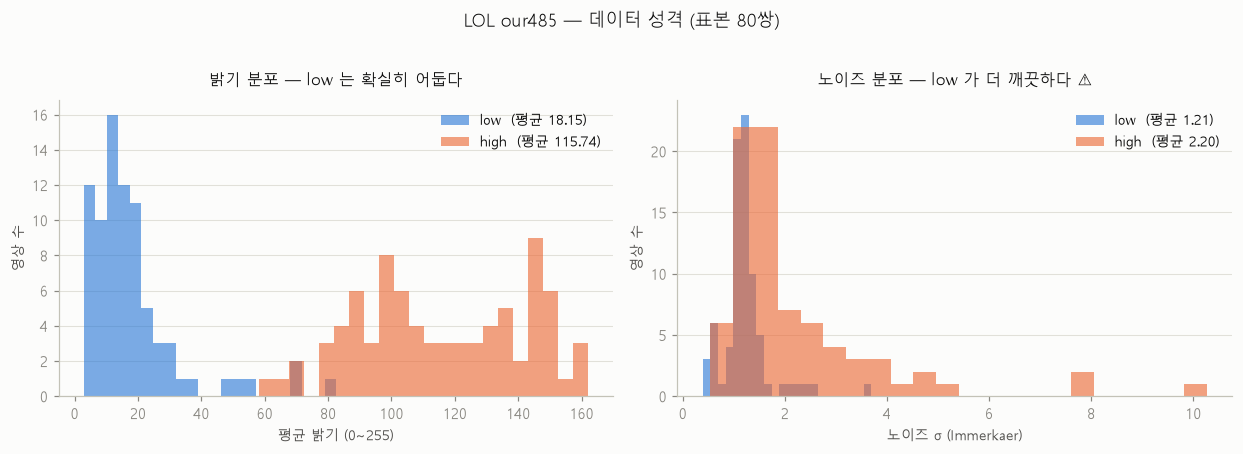

실제 야간 촬영이면 광량 부족으로 low 의 노이즈가 high 보다 **많아야** 한다.
반대로 나온다는 것은 밝은 원본을 어둡게 만든 합성본이라는 뜻이다.
→ docs/lowlight_classical.md 6-2-1 의 LoLI-Street 검증과 같은 결론.


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.0))
SIDE_COLOR = {"low": "#2a78d6", "high": "#eb6834"}

# 밝기와 노이즈는 단위가 달라 **축을 공유하지 않는다** (하나의 그림에 두 y축을
# 두면 어느 쪽 눈금인지 읽을 수 없다). 서브플롯으로 분리한다.
for ax, col, title, xlabel in (
    (ax1, 0, "밝기 분포 — low 는 확실히 어둡다", "평균 밝기 (0~255)"),
    (ax2, 2, "노이즈 분포 — low 가 더 깨끗하다 ⚠️", "노이즈 σ (Immerkaer)"),
):
    for side in ("low", "high"):
        v = prof[("our485", side)][:, col]
        ax.hist(v, bins=22, color=SIDE_COLOR[side], alpha=0.62,
                label=f"{side}  (평균 {v.mean():.2f})", zorder=2)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK)
    ax.set_title(title, fontsize=10.5, color=INK, pad=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("영상 수", fontsize=9)
    ax.grid(axis="y", lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.suptitle("LOL our485 — 데이터 성격 (표본 80쌍)", fontsize=12, color=INK, y=1.02)
fig.tight_layout()
plt.show()

print("실제 야간 촬영이면 광량 부족으로 low 의 노이즈가 high 보다 **많아야** 한다.")
print("반대로 나온다는 것은 밝은 원본을 어둡게 만든 합성본이라는 뜻이다.")
print("→ docs/lowlight_classical.md 6-2-1 의 LoLI-Street 검증과 같은 결론.")

## 2. 표본 선택

`eval15` (공식 평가 split) 를 쓴다. `our485` 는 학습용이라 평가에 쓰면 안 된다.

시각 비교용으로는 **암부 비중이 큰 순서**로 4장을 고른다 — 저조도 개선의 차이가
가장 잘 드러나는 장면이다. 수치는 `eval15` 15쌍 전량으로 계산한다.

In [22]:
def load_pair(pair):
    lo, hi = (cv2.imread(str(p)) for p in pair)
    assert lo is not None and hi is not None, f"읽기 실패: {pair}"
    return lo, hi


eval_pairs = [(*load_pair(pr), pr[0].name) for pr in splits["eval15"]]
lows = [lo for lo, _, _ in eval_pairs]
highs = [hi for _, hi, _ in eval_pairs]

# 밝기 순으로 정렬해 **고르게** 4장을 뽑는다.
# LOL low 는 전부 극단적으로 어두워(암부<30 비중이 대부분 99~100%) "어두운 순"으로
# 고르면 사실상 임의 선택이 된다. 밝기 범위를 균등 분할해 장면 다양성을 확보한다.
VIEW_N = 4
order = np.argsort([float(luma(lo).mean()) for lo in lows])
picks = order[np.linspace(0, len(order) - 1, VIEW_N).round().astype(int)]
view = [eval_pairs[i] for i in picks]

print(f"수치 표본: eval15 전량 {len(eval_pairs)}쌍")
print(f"시각 표본: 밝기 범위를 균등 분할한 {VIEW_N}장 (어두운 → 밝은 순)\n")
print(f"{'파일':<12}{'해상도':>12}{'평균밝기':>10}{'암부<30 비중':>14}")
print("-" * 48)
for lo, _, name in view:
    L = luma(lo)
    print(f"{name:<12}{f'{lo.shape[1]}x{lo.shape[0]}':>12}"
          f"{L.mean():>10.1f}{100 * (L < 30).mean():>13.1f}%")

수치 표본: eval15 전량 15쌍
시각 표본: 밝기 범위를 균등 분할한 4장 (어두운 → 밝은 순)

파일                   해상도      평균밝기      암부<30 비중
------------------------------------------------
493.png          600x400       6.4        100.0%
780.png          600x400      10.5         96.1%
111.png          600x400      19.3         91.6%
1.png            600x400      24.6         68.1%


## 3. 전체 비교 그리드 ★

**행 = 표본, 열 = `원본 → 각 arm → GT`.**

> 원본 열이 거의 검게 보이는 것은 렌더링 문제가 아니다 — LOL `low` 의 평균 밝기가
> **12 정도**라 실제로 그만큼 어둡다. 각 기법이 이걸 어디까지 끌어올리는지가 이 그림의 요점이다.

**보는 순서**
1. 원본과 비교해 **암부에서 무엇이 새로 보이는가**
2. GT 와 비교해 **색이 어떻게 어긋나는가** — 문서 6-3-4 는 두 종류를 구분한다:
   *탈색*(채도가 빠짐, A1/A2 의 LAB `L`만 올리는 구조 탓)과 *캐스트*(색이 한쪽으로 쏠림,
   톤매핑 계열). **어느 arm 이 어느 쪽인지 직접 분류해 볼 것** — 두 결함은 대응책이 다르다
3. 밝은 영역이 **흰색으로 뭉개지지 않는가**

> `none` 열은 넣지 않았다 — 항등 arm 이라 `원본` 열과 같은 이미지가 나온다.
> 대조군으로서의 역할은 6·7절 수치표에서 한다.

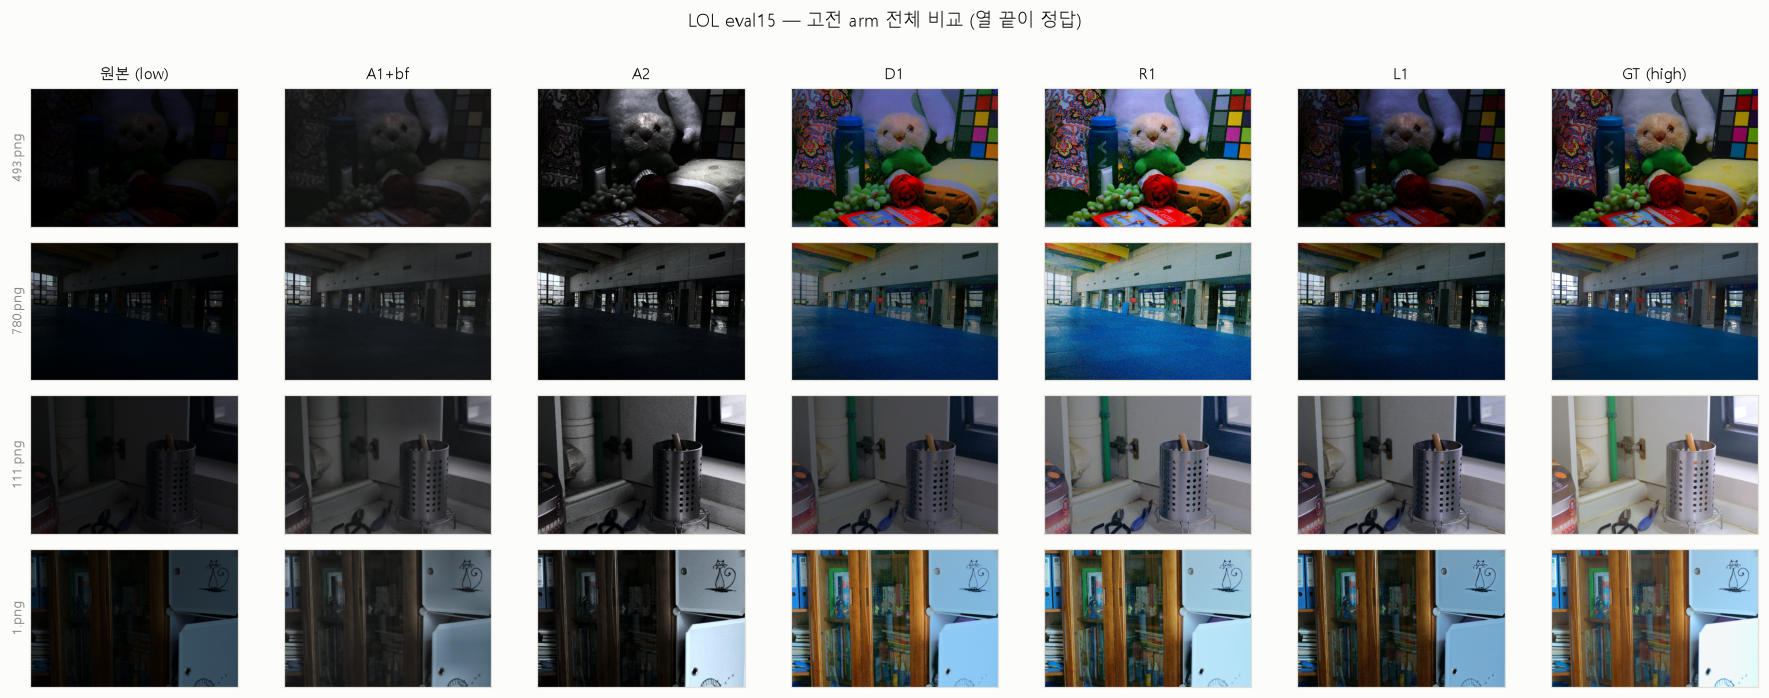

확인할 것 — 단정하지 말고 직접 보고 판단한다:
  (a) GT 에 가장 가까운 밝기를 내는 arm 은 어느 것인가
  (b) A1+bf·A2 는 GT 보다 어둡게 남는가 (LOL low 는 평균밝기 15 라 증폭 요구가 크다)
  (c) 색이 어긋나는 방식이 arm 마다 다른가 — 빠지는가(탈색) 쏠리는가(캐스트)

※ 문서 6-3 의 육안 순위는 **실제 야간(ExDark 등)** 기준이다. LOL 은 성격이
  다른 데이터이므로(1절) 여기서 순위가 달라도 문서가 틀린 것이 아니다.


In [23]:
def show_grid(items, arm_names, col_w=2.35, with_gt=True, title=None, note=None):
    """행=표본, 열=[원본 + arm들 (+GT)] 격자."""
    labels = ["원본 (low)"] + list(arm_names) + (["GT (high)"] if with_gt else [])
    cols, rows = len(labels), len(items)
    ar = items[0][0].shape[0] / items[0][0].shape[1]
    fig, axes = plt.subplots(rows, cols, figsize=(col_w * cols, col_w * ar * rows))
    axes = np.atleast_2d(axes)

    for r, (lo, hi, name) in enumerate(items):
        cells = [lo] + [arms[n](lo) for n in arm_names] + ([hi] if with_gt else [])
        for c, out in enumerate(cells):
            ax = axes[r, c]
            ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
            ax.set_xticks([])
            ax.set_yticks([])
            for s in ax.spines.values():
                s.set_color(RULE)
            if r == 0:
                # 라벨 색은 ink 고정 — 시리즈 색을 글자에 입히지 않는다
                ax.set_title(labels[c], fontsize=9.5, color=INK, pad=6)
            if c == 0:
                ax.set_ylabel(name, fontsize=8.5, color=MUTED)

    if title:
        fig.suptitle(title, fontsize=12, color=INK, y=1.005)
    fig.tight_layout()
    plt.show()
    if note:
        print(note)


show_grid(view, VIEW_ARMS,
          title="LOL eval15 — 고전 arm 전체 비교 (열 끝이 정답)",
          note="확인할 것 — 단정하지 말고 직접 보고 판단한다:\n"
               "  (a) GT 에 가장 가까운 밝기를 내는 arm 은 어느 것인가\n"
               "  (b) A1+bf·A2 는 GT 보다 어둡게 남는가 (LOL low 는 평균밝기 15 라 증폭 요구가 크다)\n"
               "  (c) 색이 어긋나는 방식이 arm 마다 다른가 — 빠지는가(탈색) 쏠리는가(캐스트)\n"
               "\n※ 문서 6-3 의 육안 순위는 **실제 야간(ExDark 등)** 기준이다. LOL 은 성격이\n"
               "  다른 데이터이므로(1절) 여기서 순위가 달라도 문서가 틀린 것이 아니다.")

### 3-1. `+bf` 를 포함한 전 arm — 레지스트리 10개 전부

위는 문서와 대조하기 위한 6-arm 뷰다. 여기서는 **`scripts/lowlight.py` 에 등록된
모든 arm**을 한 장면에 늘어놓아 `+bf`(bilateral) 유무까지 본다.

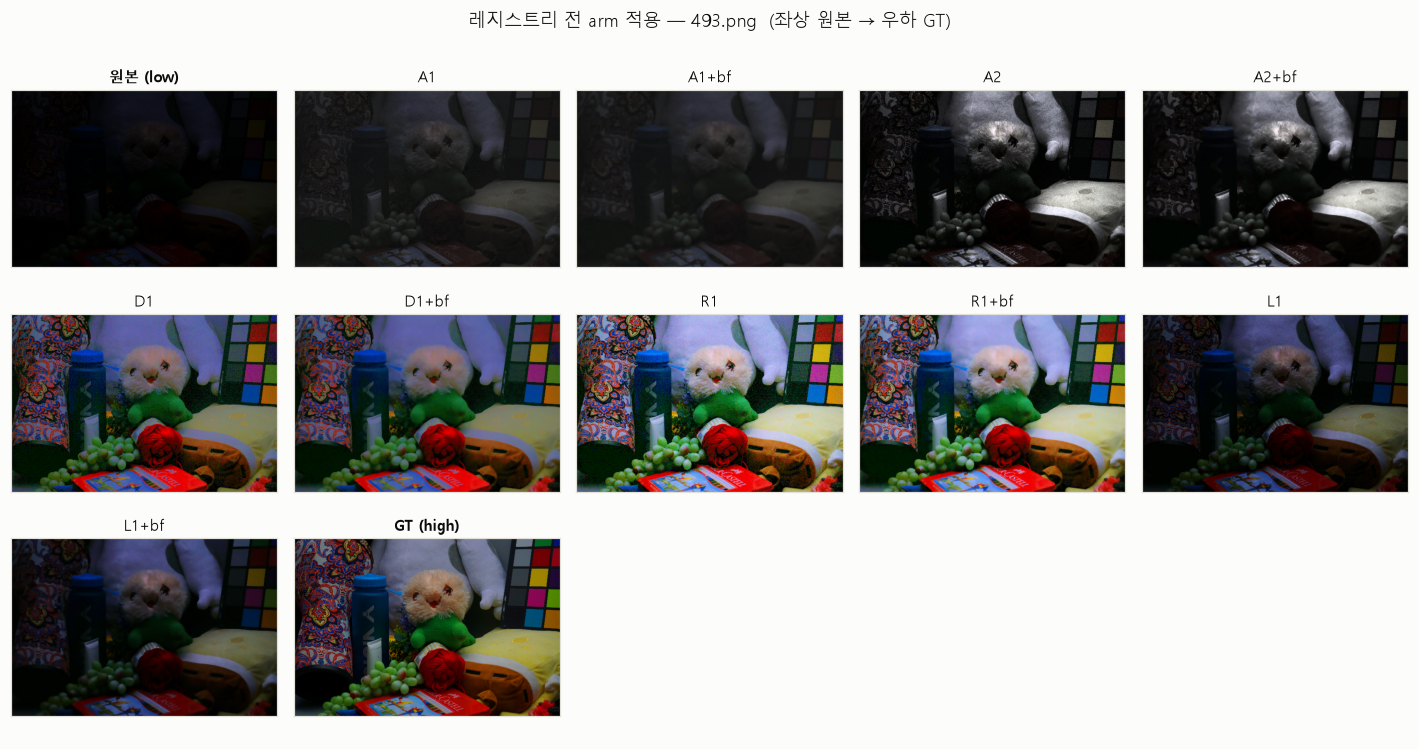

같은 톤커브의 `X` 와 `X+bf` 를 나란히 두고 볼 것.
+bf 쪽은 암부 얼룩이 줄어드는 대신 미세 디테일이 뭉개진다.
이 교환이 탐지 mAP 에서 어느 쪽으로 기우는지가 가설 H2 의 판정 지점이다.
(디테일 손실은 8-1 에서 확대해 본다)


In [24]:
def show_wrapped(item, arm_names, ncols=5, col_w=2.6, title=None, note=None):
    """한 장면에 arm 을 전부 적용해 **여러 행으로 감싸** 배치한다.

    13개를 한 줄에 늘어놓으면 셀이 손톱만 해져 아무것도 안 보인다(폭 23인치·높이 1.3인치).
    행을 접어야 각 셀이 볼 수 있는 크기를 유지한다.
    """
    lo, hi, fname = item
    cells = ([("원본 (low)", lo)]
             + [(n, arms[n](lo)) for n in arm_names]
             + [("GT (high)", hi)])
    nrows = -(-len(cells) // ncols)  # 천장 나눗셈
    ar = lo.shape[0] / lo.shape[1]
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(col_w * ncols, col_w * ar * nrows * 1.30))
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(hspace=0.28)  # 아랫줄 제목이 윗줄 이미지에 붙지 않게

    for i, ax in enumerate(axes.ravel()):
        if i >= len(cells):
            ax.axis("off")  # 남는 칸은 지운다
            continue
        label, out = cells[i]
        ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(RULE)
        # 원본·GT 는 기준이므로 라벨을 굵게 해 arm 과 구분한다
        ax.set_title(label, fontsize=9.5, color=INK, pad=5,
                     fontweight="bold" if i in (0, len(cells) - 1) else "normal")

    if title:
        fig.suptitle(title, fontsize=12, color=INK, y=1.0)
    fig.tight_layout()
    plt.show()
    if note:
        print(note)


show_wrapped(view[0], [n for n in ARM_NAMES if n != "none"], ncols=5,
             title=f"레지스트리 전 arm 적용 — {view[0][2]}  (좌상 원본 → 우하 GT)",
             note="같은 톤커브의 `X` 와 `X+bf` 를 나란히 두고 볼 것.\n"
                  "+bf 쪽은 암부 얼룩이 줄어드는 대신 미세 디테일이 뭉개진다.\n"
                  "이 교환이 탐지 mAP 에서 어느 쪽으로 기우는지가 가설 H2 의 판정 지점이다.\n"
                  "(디테일 손실은 8-1 에서 확대해 본다)")

## 4. 톤커브 실측 — 각 기법이 어느 밝기를 올리고 내리는가

표본 전체의 픽셀을 **입력 휘도 → 출력 휘도**로 모아 중앙값 곡선을 그린다.
CLAHE 처럼 국소적으로 동작하는 기법도 포함해 *실제* 전달 특성이 나온다.

**읽는 법** — 회색 점선(항등선)보다 **위**면 그 밝기를 올린 것, **아래**면 내린 것.

> ⚠️ **LOL 에서는 곡선의 오른쪽(밝은 영역)이 비어 있다.** `low` 에 밝은 픽셀이
> 거의 없기 때문이다. 즉 **이 데이터로는 강광원 거동을 볼 수 없다** — 1절의
> "포화 0.00%" 가 그림으로 나타나는 지점이다. 하이라이트 판정은 실제 야간
> 데이터로만 가능하다.

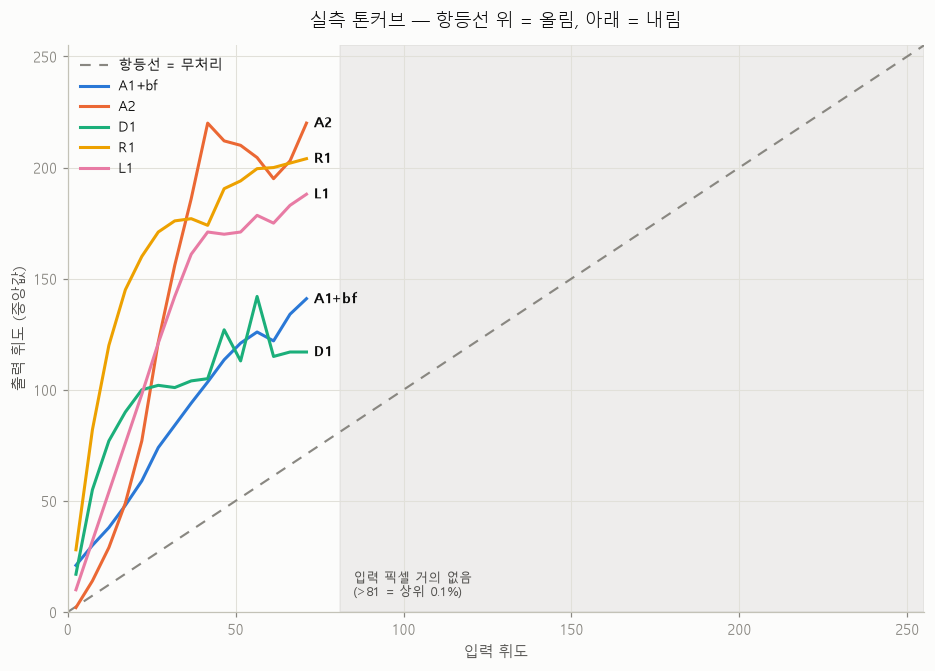

암부(왼쪽)에서 곡선이 얼마나 솟는가 = 저조도 개선의 강도다.
A2(AGCWD)가 가장 공격적으로 밀어올리고, D1(Drago)은 완만하다.

⚠️ 오른쪽 음영 구간은 입력 표본이 없어 곡선이 그려지지 않는다.
   '어느 기법이 강광원을 누르는가'는 이 데이터로 답할 수 없다.


In [25]:
def tone_curve(arm, images, bins=52, min_px=200, min_imgs=3):
    """입력 휘도 -> 출력 휘도 실측 전달함수.

    영상마다 곡선을 따로 구한 뒤 영상 간 중앙값을 취한다. 전체 픽셀을 한 번에
    모으면 밝은 영상이 곡선을 지배하고 구간 표본이 들쭉날쭉해진다.
    min_px 미만인 구간은 버린다.
    """
    edges = np.linspace(0, 255, bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2

    per_image = []
    for img in images:
        x, y = luma(img).ravel(), luma(arm(img)).ravel()
        slot = np.clip(np.digitize(x, edges) - 1, 0, bins - 1)
        med = np.full(bins, np.nan)
        for b in range(bins):
            m = slot == b
            if m.sum() >= min_px:
                med[b] = np.median(y[m])
        per_image.append(med)

    stack = np.vstack(per_image)
    enough = np.isfinite(stack).sum(axis=0) >= min_imgs
    if not enough.any():
        return np.array([]), np.array([])
    # 전량 NaN 인 구간을 nanmedian 에 넘기면 경고가 난다 — 먼저 걸러낸다
    return centers[enough], np.nanmedian(stack[:, enough], axis=0)


# 입력 픽셀이 실제로 어디에 분포하는지 — 곡선의 신뢰 구간을 알려준다
all_lo = np.concatenate([luma(lo).ravel() for lo in lows])
p_hi = float(np.percentile(all_lo, 99.9))

fig, ax = plt.subplots(figsize=(8.6, 6.2))

ax.axvspan(p_hi, 255, color=MUTED, alpha=0.12, zorder=0)
ax.text(min(p_hi + 4, 250), 6,
        f"입력 픽셀 거의 없음\n(>{p_hi:.0f} = 상위 0.1%)",
        fontsize=8.5, color="#52514e", va="bottom", ha="left")
ax.plot([0, 255], [0, 255], color=MUTED, lw=1.4, ls=(0, (5, 4)), zorder=1,
        label="항등선 = 무처리")

for name in ARMS:
    if name == "none":
        continue  # 정의상 항등선과 겹친다
    cx, cy = tone_curve(arms[name], lows)
    ax.plot(cx, cy, color=ARM_COLOR[name], lw=2.0, zorder=3, label=name)
    # 선 끝에 직접 라벨 — 팔레트 대비 WARN 에 대한 relief (색만으로 식별하지 않는다)
    ax.annotate(name, (cx[-1], cy[-1]), xytext=(5, 0), textcoords="offset points",
                fontsize=9, color=INK, va="center", fontweight="bold")

ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_xlabel("입력 휘도", fontsize=9.5)
ax.set_ylabel("출력 휘도 (중앙값)", fontsize=9.5)
ax.set_title("실측 톤커브 — 항등선 위 = 올림, 아래 = 내림",
             fontsize=12, color=INK, pad=12)
ax.legend(frameon=False, fontsize=9, loc="upper left", labelcolor=INK)
ax.grid(lw=0.7, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

print("암부(왼쪽)에서 곡선이 얼마나 솟는가 = 저조도 개선의 강도다.")
print("A2(AGCWD)가 가장 공격적으로 밀어올리고, D1(Drago)은 완만하다.")
print("\n⚠️ 오른쪽 음영 구간은 입력 표본이 없어 곡선이 그려지지 않는다.")
print("   '어느 기법이 강광원을 누르는가'는 이 데이터로 답할 수 없다.")

## 5. 암부 확대 — 노이즈가 얼마나 드러나는가

어둡고 **평탄한** 영역을 잘라 확대한다. 구조가 없는 곳이라 보이는 얼룩은 전부 노이즈다.

> ⚠️ `docs/lowlight_classical.md` 6-3-4 — **현재 노이즈 지표는 여기서 보이는 것과
> 반대 결론을 낸다.** 지표는 전역 밝기이득으로 정규화하는데, 톤매핑 계열은 암부를
> 크게 끌어올려 *원래 안 보이던 노이즈를 드러내면서* 밝기이득도 함께 키우기 때문이다.
> **이 그림이 지표보다 신뢰할 만하다.**

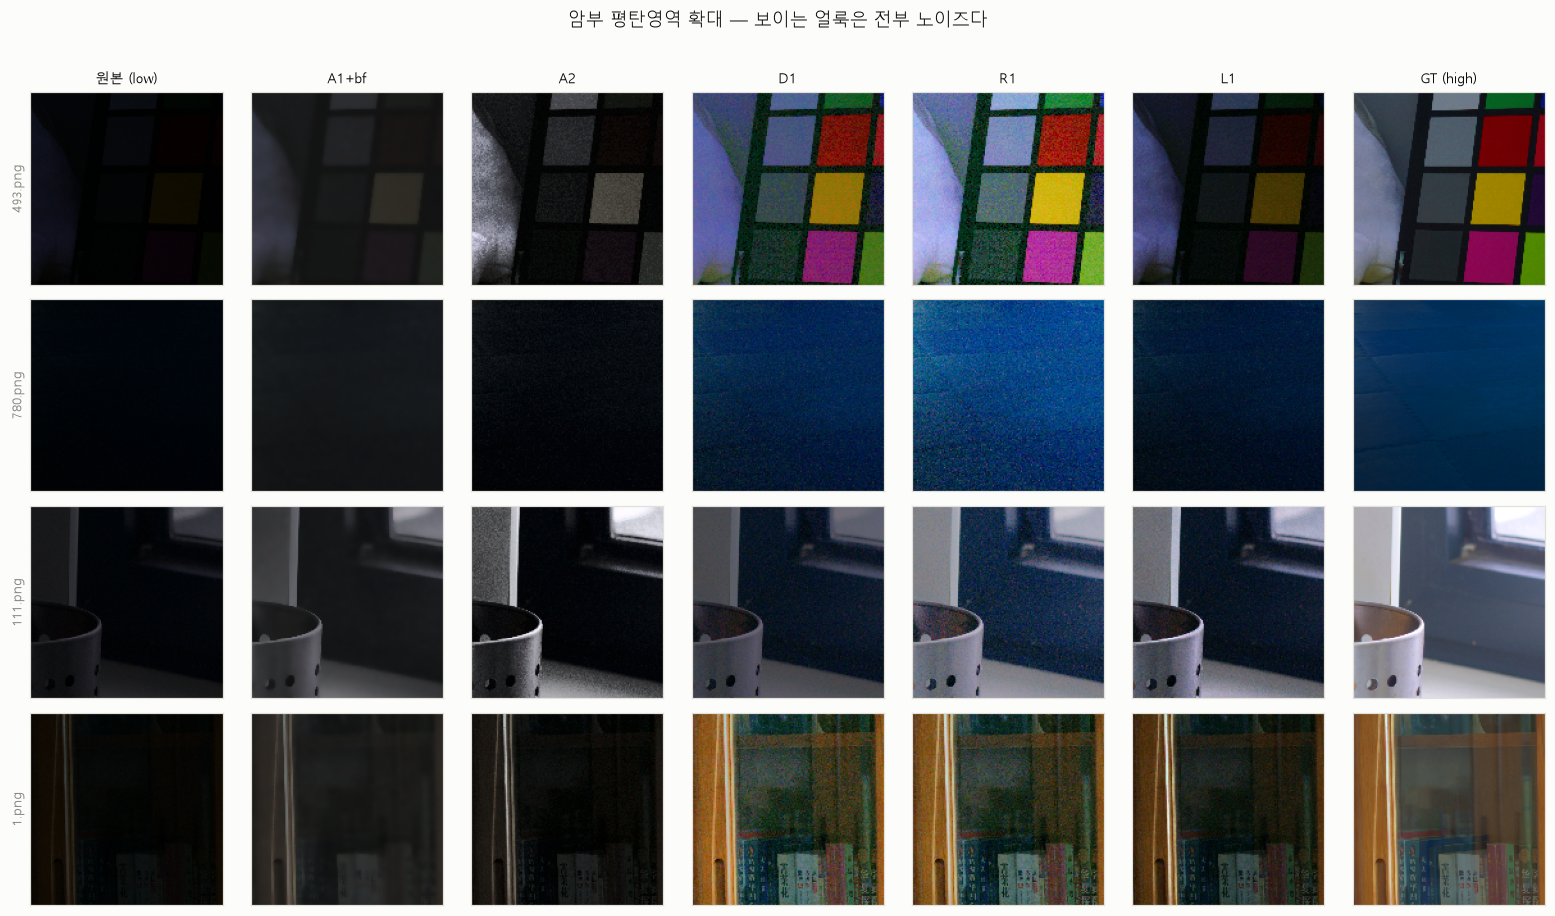

컬러 얼룩이 심할수록 탐지기 입력으로도, 표시용으로도 불리하다.
문서 6-3-4 는 실제 야간에서 **D1·R1·L1 셋 다** 노이즈가 심하다고 보고한다.
LOL 에서 셋이 갈리는지(예: L1 만 깨끗한지) 직접 확인할 것 — 갈린다면
'톤매핑 계열은 노이즈가 심하다'는 계열 단위 서술이 너무 거친 것이다.

그리고 7절의 노이즈증폭 수치와 **반대인지** 대조하라. 반대라면 지표가 틀렸다.


In [26]:
def darkest_flat_spot(img, size):
    """어두우면서 국소 대비가 낮은 곳 = 구조가 없어 노이즈만 남는 영역."""
    L = luma(img)
    k = (25, 25)
    mean = cv2.blur(L, k)
    var = cv2.blur(L * L, k) - mean * mean
    score = np.where(mean < 4, np.inf, mean + 3.0 * np.sqrt(np.maximum(var, 0)))
    half = size // 2
    inner = score[half:-half or None, half:-half or None]
    if inner.size == 0:
        return L.shape[0] // 2, L.shape[1] // 2
    y, x = np.unravel_index(np.argmin(inner), inner.shape)
    return y + half, x + half


def show_crops(items, arm_names, locator, size=150, col_w=2.05, title=None, note=None):
    """확대 크롭 격자. 자를 위치는 **원본에서** 정하고 전 arm 에 같은 좌표를 쓴다."""
    labels = ["원본 (low)"] + list(arm_names) + ["GT (high)"]
    fig, axes = plt.subplots(len(items), len(labels),
                             figsize=(col_w * len(labels), col_w * len(items)))
    axes = np.atleast_2d(axes)

    for r, (lo, hi, name) in enumerate(items):
        cy, cx = locator(lo, size)
        h, w = lo.shape[:2]
        half = size // 2
        y0 = int(np.clip(cy - half, 0, max(0, h - size)))
        x0 = int(np.clip(cx - half, 0, max(0, w - size)))
        cells = [lo] + [arms[n](lo) for n in arm_names] + [hi]
        for c, out in enumerate(cells):
            ax = axes[r, c]
            ax.imshow(cv2.cvtColor(out[y0:y0 + size, x0:x0 + size], cv2.COLOR_BGR2RGB))
            ax.set_xticks([])
            ax.set_yticks([])
            for s in ax.spines.values():
                s.set_color(RULE)
            if r == 0:
                ax.set_title(labels[c], fontsize=9, color=INK, pad=6)
            if c == 0:
                ax.set_ylabel(name, fontsize=8.5, color=MUTED)

    if title:
        fig.suptitle(title, fontsize=12, color=INK, y=1.01)
    fig.tight_layout()
    plt.show()
    if note:
        print(note)


show_crops(view, VIEW_ARMS, darkest_flat_spot,
           title="암부 평탄영역 확대 — 보이는 얼룩은 전부 노이즈다",
           note="컬러 얼룩이 심할수록 탐지기 입력으로도, 표시용으로도 불리하다.\n"
                "문서 6-3-4 는 실제 야간에서 **D1·R1·L1 셋 다** 노이즈가 심하다고 보고한다.\n"
                "LOL 에서 셋이 갈리는지(예: L1 만 깨끗한지) 직접 확인할 것 — 갈린다면\n"
                "'톤매핑 계열은 노이즈가 심하다'는 계열 단위 서술이 너무 거친 것이다.\n"
                "\n그리고 7절의 노이즈증폭 수치와 **반대인지** 대조하라. 반대라면 지표가 틀렸다.")

## 6. GT 기반 화질 지표 — **LOL 에서만 가능하다** ★

`night_eval.py` 는 paired GT 가 없어 PSNR/SSIM 을 재지 못했다. LOL 은 쌍이 있으니
여기서만 잴 수 있다.

> ⚠️ **PSNR/SSIM 은 "GT 재현" 지표이지 "야간 보행 유용성" 지표가 아니다.**
> `docs/data.md` 2-3-1 의 **가설 H1** 이 정확히 이 지점을 겨눈다 — 본 프로젝트의
> 목적함수는 GT 재현이 아니라 **대비 강조**다. 게다가 여기서의 GT 는 *주간 장면*이라,
> PSNR 이 높다는 것은 **"주간처럼 보이게 만들었다"**는 뜻일 뿐이다.
> **순위를 채택 근거로 쓰지 말 것.** 문서 6-1 의 관측(A2 가 PSNR 우세 / A1 이 SSIM 우세)이
> 재현되는지만 확인한다.

LPIPS 는 사전학습 가중치 다운로드가 필요해 여기서는 생략한다 (`pyproject.toml` 에 의존성은 있다).

In [27]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity  # noqa: E402


def gt_metrics(arm, pairs):
    """arm 출력 vs GT 의 PSNR/SSIM. 둘 다 높을수록 GT 에 가깝다."""
    ps, ss = [], []
    for lo, hi, _ in pairs:
        out = arm(lo)
        ps.append(peak_signal_noise_ratio(hi, out, data_range=255))
        ss.append(structural_similarity(hi, out, channel_axis=2, data_range=255))
    return float(np.mean(ps)), float(np.mean(ss))


gt = {n: gt_metrics(arms[n], eval_pairs) for n in ARMS}

print(f"LOL eval15 {len(eval_pairs)}쌍 · GT(high) 기준\n")
print(f"{'arm':<8}{'PSNR (dB)':>12}{'SSIM':>10}")
print("-" * 30)
for n in ARMS:
    print(f"{n:<8}{gt[n][0]:>12.2f}{gt[n][1]:>10.3f}")

best_psnr = max(ARMS, key=lambda n: gt[n][0])
best_ssim = max(ARMS, key=lambda n: gt[n][1])
print(f"\nPSNR 최고: {best_psnr}   SSIM 최고: {best_ssim}")
if best_psnr != best_ssim:
    print("→ 두 지표가 서로 다른 arm 을 가리킨다. 단일 화질 지표로는 arm 을 고를 수 없다(H1).")

# ★ 문서 6-3-4 에서 **육안으로 기각**된 계열(D1/R1/L1 — 노이즈·색캐스트)과
#   육안 1위(A1+bf)를 GT 지표에서 맞대어 본다. 여기서 순위가 뒤집히면 H1 의 직접 증거다.
tm = [n for n in ("D1", "R1", "L1") if n in gt]
hist = [n for n in ("A1+bf", "A2") if n in gt]
tm_best = max(tm, key=lambda n: gt[n][0])
hist_best = max(hist, key=lambda n: gt[n][0])
print(f"\n[H1 점검] 톤매핑 계열 최고 {tm_best} PSNR {gt[tm_best][0]:.2f} "
      f"vs 히스토그램 계열 최고 {hist_best} PSNR {gt[hist_best][0]:.2f}")
if gt[tm_best][0] > gt[hist_best][0]:
    print("  ⇒ ★ 육안으로 기각됐던 톤매핑 계열이 GT 지표에서는 이긴다.")
    print("     '지표 우위 ≠ 실효 우위'(H1)의 직접 증거다. 5절 암부 확대와 대조할 것.")

LOL eval15 15쌍 · GT(high) 기준

arm        PSNR (dB)      SSIM
------------------------------
none            7.77     0.191
A1+bf          10.73     0.504
A2             11.79     0.343
D1             14.81     0.524
R1             17.08     0.522
L1             14.19     0.499

PSNR 최고: R1   SSIM 최고: D1
→ 두 지표가 서로 다른 arm 을 가리킨다. 단일 화질 지표로는 arm 을 고를 수 없다(H1).

[H1 점검] 톤매핑 계열 최고 R1 PSNR 17.08 vs 히스토그램 계열 최고 A2 PSNR 11.79
  ⇒ ★ 육안으로 기각됐던 톤매핑 계열이 GT 지표에서는 이긴다.
     '지표 우위 ≠ 실효 우위'(H1)의 직접 증거다. 5절 암부 확대와 대조할 것.


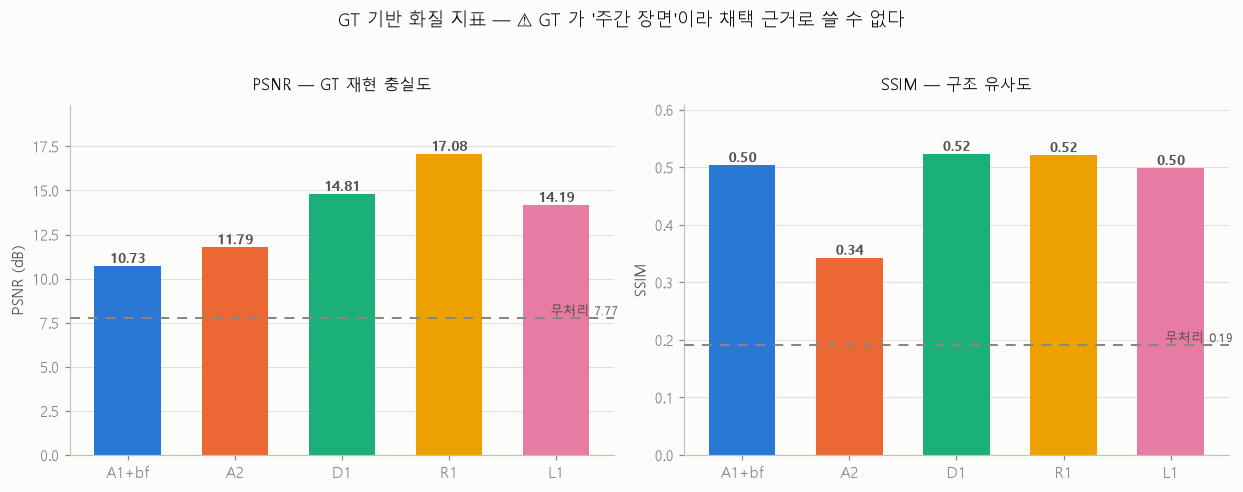

In [28]:
series = [n for n in ARMS if n != "none"]

# PSNR(dB)과 SSIM(0~1)은 단위가 달라 **절대 한 축에 겹치지 않는다.**
# 서브플롯으로 분리하고 각자 자기 축을 갖는다.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.3))

for ax, idx, label, title in (
    (ax1, 0, "PSNR (dB)", "PSNR — GT 재현 충실도"),
    (ax2, 1, "SSIM", "SSIM — 구조 유사도"),
):
    vals = [gt[n][idx] for n in series]
    ctrl = gt["none"][idx]
    bars = ax.bar(series, vals, color=[ARM_COLOR[n] for n in series],
                  width=0.62, zorder=2)
    # 대조군(무처리) 기준선 — 이보다 위여야 개선이다
    ax.axhline(ctrl, color=MUTED, lw=1.3, ls=(0, (5, 4)), zorder=3)
    ax.text(len(series) - 0.42, ctrl, f" 무처리 {ctrl:.2f}", fontsize=8.5,
            color="#52514e", va="bottom", ha="right")
    # 값 직접 라벨 — 팔레트 contrast WARN 에 대한 relief
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center",
                va="bottom", fontsize=9, color="#52514e", fontweight="bold")
    ax.set_ylabel(label, fontsize=9.5)
    ax.set_title(title, fontsize=10.5, color=INK, pad=10)
    ax.set_ylim(0, max(vals + [ctrl]) * 1.16)
    ax.grid(axis="y", lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.suptitle("GT 기반 화질 지표 — ⚠️ GT 가 '주간 장면'이라 채택 근거로 쓸 수 없다",
             fontsize=12, color=INK, y=1.03)
fig.tight_layout()
plt.show()

## 7. 목적 축 — 대비 · 노이즈

`scripts/night_eval.py` 의 **`measure()` 를 그대로** 호출한다. 문서 수치와 같은
정의로 계산해야 비교가 성립한다.

| 축 | 목적 | 읽는 법 |
|----|------|---------|
| 정규화 대비 | "밝기가 아닌 대비 중심" | **> 1.0** 이어야 단순 밝히기가 아니다 |
| 노이즈 증폭 | 가설 H2 | **> 1.0** 이면 신호보다 노이즈를 더 키운 것 |
| 강광원 변화 | 눈부심 억제 | 음수여야 억제 — **LOL 에서는 무의미** (1절) |

> ⚠️ 강광원 열도 계산은 되지만 **해석하지 말 것.** `low` 의 상위 1% 는 가로등이 아니라
> 그냥 "덜 어두운 픽셀"이다. 이 데이터에서 나오는 글레어 수치는 물리적 의미가 없다.

In [29]:
stats = {n: measure(arms[n], lows) for n in ARMS}

print(f"LOL eval15 {len(lows)}장 · night_eval.measure() 동일 정의\n")
print(f"{'arm':<8}{'정규화대비':>12}{'노이즈증폭':>12}{'밝기배율':>11}"
      f"{'  |  (참고·무의미) 강광원Δ':>26}")
print("-" * 70)
for n in ARMS:
    s = stats[n]
    print(f"{n:<8}{s['norm_contrast']:>12.2f}{s['noise_amp']:>12.3f}"
          f"{s['gain']:>10.2f}x{s['glare_after'] - s['glare_before']:>+22.1f}")

print("\n⚠️ 노이즈증폭 지표는 문서 6-3-4 기준 신뢰할 수 없다 — 5절 그림과 대조할 것.")
print("⚠️ 강광원Δ 는 LOL 에 강광원이 없으므로 해석 금지 (1절).")

# 극단적 저조도에서 정규화 대비 지표가 어떻게 무너지는지 — 지표 재설계의 추가 근거
below = [n for n in series if stats[n]["norm_contrast"] < 1.0]
if below:
    gains = ", ".join(f"{n} {stats[n]['gain']:.1f}x" for n in below)
    print(f"\n★ 관측 — 정규화 대비가 1.0 미만인 arm: {', '.join(below)}")
    print(f"   이들의 밝기배율이 크다({gains}). LOL low 는 평균밝기 15 수준이라")
    print("   어떤 arm 이든 밝기를 3~9배 올리는데, 지표는 그 이득으로 나누기 때문에")
    print("   대비가 실제로 늘었어도 1.0 아래로 떨어진다.")
    print("   ⇒ **정규화 대비 지표도 극단적 저조도에서 신뢰할 수 없다.** 문서 7장의")
    print("      '노이즈 지표 재설계' 항목에 대비 지표까지 포함해야 한다는 근거.")

LOL eval15 15장 · night_eval.measure() 동일 정의

arm            정규화대비       노이즈증폭       밝기배율          |  (참고·무의미) 강광원Δ
----------------------------------------------------------------------
none            1.00       1.000      1.00x                  +0.0
A1+bf           0.49       0.209      3.21x                 +57.7
A2              1.18       1.584      4.06x                +180.5
D1              0.88       0.839      5.11x                 +70.7
R1              0.83       0.785      8.65x                +142.1
L1              1.01       0.993      4.37x                +110.3

⚠️ 노이즈증폭 지표는 문서 6-3-4 기준 신뢰할 수 없다 — 5절 그림과 대조할 것.
⚠️ 강광원Δ 는 LOL 에 강광원이 없으므로 해석 금지 (1절).

★ 관측 — 정규화 대비가 1.0 미만인 arm: A1+bf, D1, R1
   이들의 밝기배율이 크다(A1+bf 3.2x, D1 5.1x, R1 8.7x). LOL low 는 평균밝기 15 수준이라
   어떤 arm 이든 밝기를 3~9배 올리는데, 지표는 그 이득으로 나누기 때문에
   대비가 실제로 늘었어도 1.0 아래로 떨어진다.
   ⇒ **정규화 대비 지표도 극단적 저조도에서 신뢰할 수 없다.** 문서 7장의
      '노이즈 지표 재설계' 항목에 대비 지표까지 포함해야 한다는 근거.


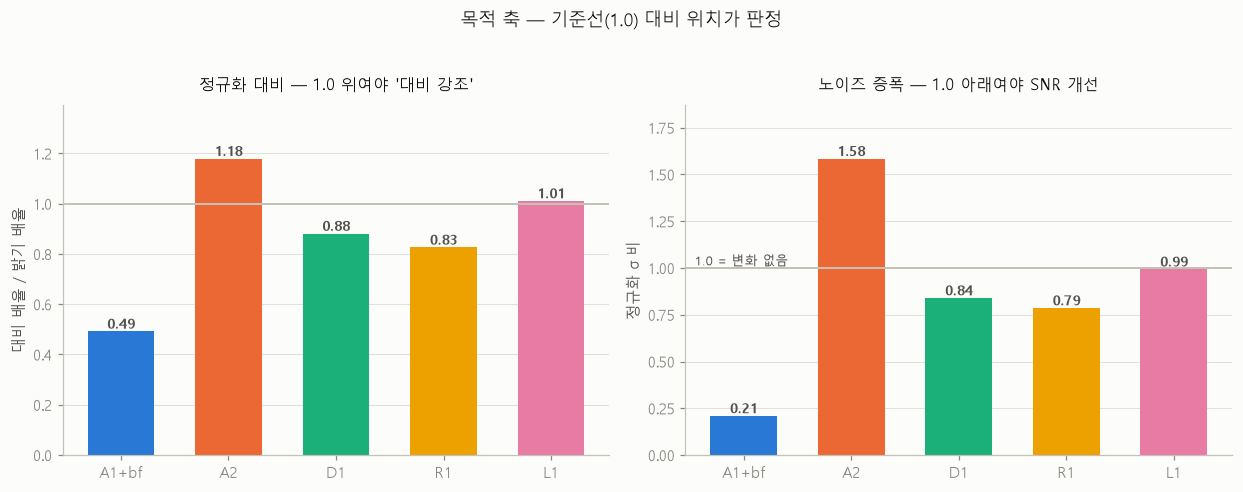

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.3))

for ax, key, title, ylabel in (
    (ax1, "norm_contrast", "정규화 대비 — 1.0 위여야 '대비 강조'", "대비 배율 / 밝기 배율"),
    (ax2, "noise_amp", "노이즈 증폭 — 1.0 아래여야 SNR 개선", "정규화 σ 비"),
):
    vals = [stats[n][key] for n in series]
    bars = ax.bar(series, vals, color=[ARM_COLOR[n] for n in series],
                  width=0.62, zorder=2)
    ax.axhline(1.0, color="#c3c2b7", lw=1.3, zorder=3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center",
                va="bottom", fontsize=9, color="#52514e", fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9.5)
    ax.set_title(title, fontsize=10.5, color=INK, pad=10)
    ax.set_ylim(0, max(vals + [1.0]) * 1.18)
    ax.grid(axis="y", lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# 기준선 라벨은 왼쪽에 — 오른쪽 끝은 마지막 막대의 값 라벨과 겹친다
ax2.text(-0.45, 1.0, "1.0 = 변화 없음", fontsize=8.5,
         color="#52514e", va="bottom", ha="left")
fig.suptitle("목적 축 — 기준선(1.0) 대비 위치가 판정", fontsize=12, color=INK, y=1.03)
fig.tight_layout()
plt.show()

## 8. `+bf` 축 — 노이즈 억제를 붙이면 무엇이 바뀌는가

문서 7장의 열린 항목 **"`+bf` 를 기본값으로 승격 검토"** 에 대한 입력이다.
같은 톤커브끼리 `bf` 유무만 바꿔 비교한다 — 이렇게 짝지어야 톤커브 차이와
노이즈 처리 차이가 섞이지 않는다.

**색 = 톤커브 계열, 해칭 = bilateral 적용.** 색만으로 구분하지 않는다.

In [31]:
BF_PAIRS = [("A1", "A1+bf"), ("A2", "A2+bf"), ("D1", "D1+bf"),
            ("R1", "R1+bf"), ("L1", "L1+bf")]
BASE_COLOR = {"A1": "#2a78d6", "A2": "#eb6834", "D1": "#1baf7a",
              "R1": "#eda100", "L1": "#e87ba4"}

bf_stats = {}
for base, withbf in BF_PAIRS:
    for n in (base, withbf):
        if n not in bf_stats:
            bf_stats[n] = measure(arms[n], lows)

print(f"{'톤커브':<6}{'노이즈증폭 bf없음':>18}{'bf있음':>10}{'변화':>10}"
      f"{'   정규화대비 bf없음':>20}{'bf있음':>10}")
print("-" * 76)
for base, withbf in BF_PAIRS:
    a, b = bf_stats[base], bf_stats[withbf]
    print(f"{base:<6}{a['noise_amp']:>18.3f}{b['noise_amp']:>10.3f}"
          f"{b['noise_amp'] - a['noise_amp']:>+10.3f}"
          f"{a['norm_contrast']:>20.2f}{b['norm_contrast']:>10.2f}")

톤커브           노이즈증폭 bf없음      bf있음        변화          정규화대비 bf없음      bf있음
----------------------------------------------------------------------------
A1                 0.895     0.209    -0.686                0.78      0.49
A2                 1.584     0.754    -0.829                1.18      0.88
D1                 0.839     0.256    -0.583                0.88      0.60
R1                 0.785     0.340    -0.445                0.83      0.64
L1                 0.993     0.306    -0.687                1.01      0.72


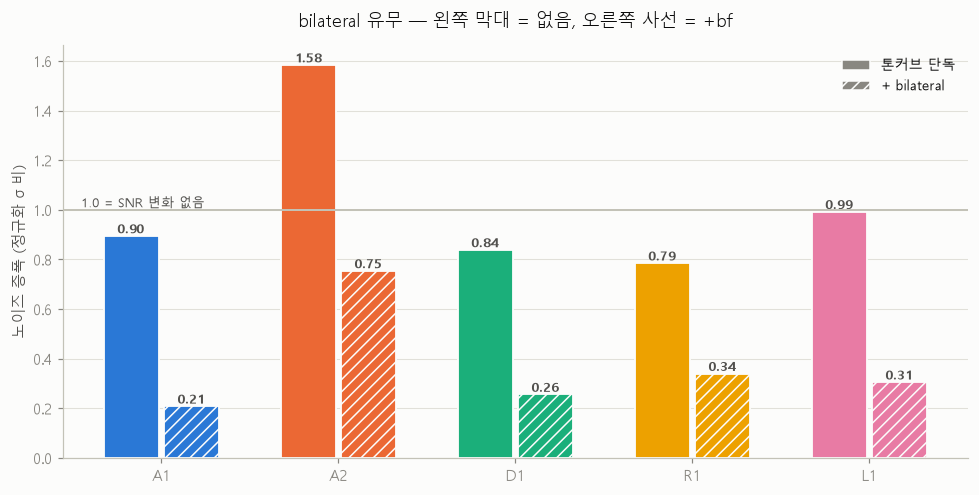

문서 6-2-3 의 4번은 실제 야간(ExDark)에서 +bf 가 A1 의 노이즈증폭을
1.087 → 0.515 로 절반 이하로 낮췄다고 보고한다. LOL(합성)에서는 개선폭이
더 작게 나올 것으로 예상된다 — 제거할 실제 노이즈가 적기 때문이다.


In [32]:
fig, ax = plt.subplots(figsize=(9.0, 4.6))
x = np.arange(len(BF_PAIRS))
w = 0.34

for i, (suffix, hatch) in enumerate(((0, None), (1, "///"))):
    vals = [bf_stats[pair[suffix]]["noise_amp"] for pair in BF_PAIRS]
    bars = ax.bar(x + (i - 0.5) * w, vals, width=w - 0.03,
                  color=[BASE_COLOR[p[0]] for p in BF_PAIRS],
                  hatch=hatch, edgecolor="#fcfcfb", linewidth=1.2, zorder=2)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center",
                va="bottom", fontsize=8.5, color="#52514e", fontweight="bold")

ax.axhline(1.0, color="#c3c2b7", lw=1.3, zorder=3)
# 기준선 라벨은 **왼쪽**에 둔다 — 오른쪽은 L1 막대의 값 라벨과 겹친다
ax.text(-0.45, 1.0, "1.0 = SNR 변화 없음 ", fontsize=8.5,
        color="#52514e", va="bottom", ha="left")
ax.set_xticks(x)
ax.set_xticklabels([p[0] for p in BF_PAIRS])
ax.set_ylabel("노이즈 증폭 (정규화 σ 비)", fontsize=9.5)
ax.set_title("bilateral 유무 — 왼쪽 막대 = 없음, 오른쪽 사선 = +bf",
             fontsize=11.5, color=INK, pad=12)

# 해칭이 무엇을 뜻하는지 범례로 명시 — 텍스처가 두 번째 부호화 채널이다
from matplotlib.patches import Patch  # noqa: E402
ax.legend(handles=[
    Patch(facecolor=MUTED, edgecolor="#fcfcfb", label="톤커브 단독"),
    Patch(facecolor=MUTED, edgecolor="#fcfcfb", hatch="///", label="+ bilateral"),
], frameon=False, fontsize=9, labelcolor=INK, loc="upper right")
ax.grid(axis="y", lw=0.7, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

print("문서 6-2-3 의 4번은 실제 야간(ExDark)에서 +bf 가 A1 의 노이즈증폭을")
print("1.087 → 0.515 로 절반 이하로 낮췄다고 보고한다. LOL(합성)에서는 개선폭이")
print("더 작게 나올 것으로 예상된다 — 제거할 실제 노이즈가 적기 때문이다.")

### 8-1. `+bf` 의 대가 — 디테일 손실을 눈으로

노이즈 지표만 보면 `+bf` 가 항상 이긴다. 그러나 bilateral 은 **미세 구조도 함께
지운다.** 탐지기 입력으로 쓸 때 이 손실이 노이즈 감소 이득보다 크면 mAP 가 떨어진다.

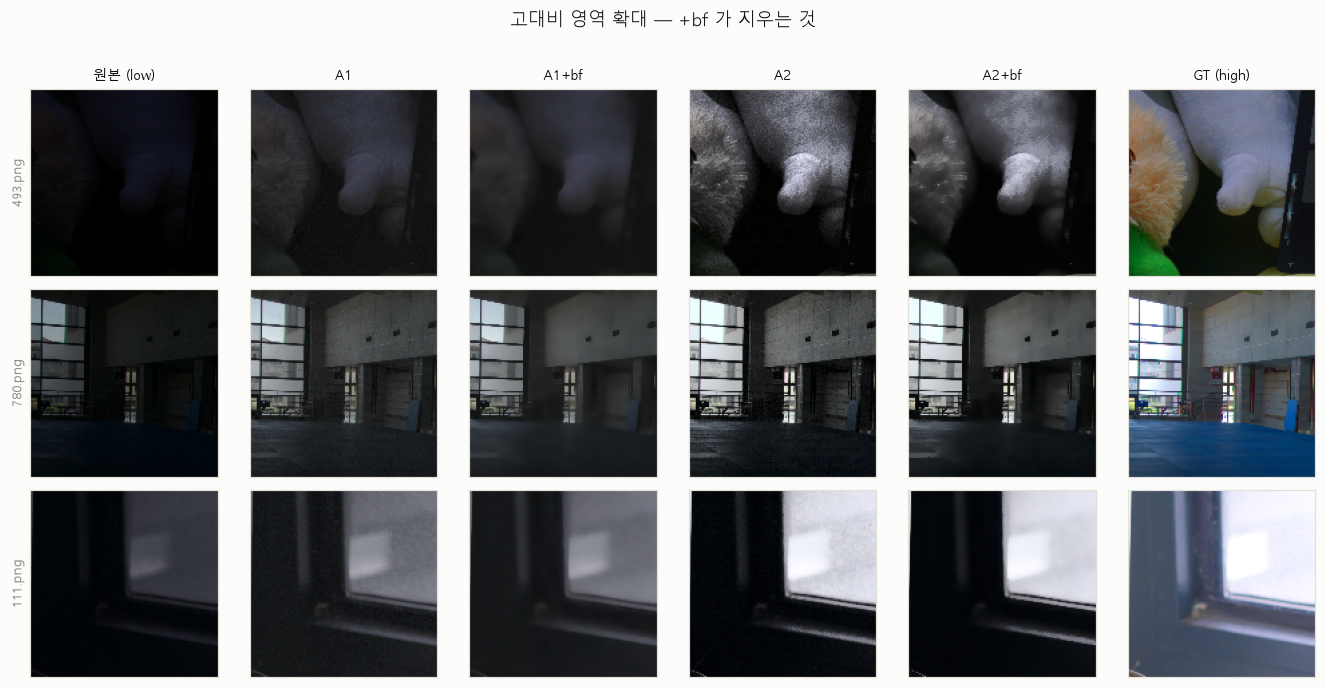

+bf 열에서 경계가 뭉개지고 질감이 사라진다면 그것이 탐지 성능의 대가다.
판정은 mAP 로만 가능하다 (docs/data.md 2-3-3 의 4-arm 실험).


In [33]:
def detail_spot(img, size):
    """국소 대비가 가장 높은 곳 = 미세 구조가 몰려 있는 영역."""
    L = luma(img)
    k = (17, 17)
    mean = cv2.blur(L, k)
    var = cv2.blur(L * L, k) - mean * mean
    half = size // 2
    inner = var[half:-half or None, half:-half or None]
    if inner.size == 0:
        return L.shape[0] // 2, L.shape[1] // 2
    y, x = np.unravel_index(np.argmax(inner), inner.shape)
    return y + half, x + half


show_crops(view[:3], ["A1", "A1+bf", "A2", "A2+bf"], detail_spot, size=140,
           title="고대비 영역 확대 — +bf 가 지우는 것",
           note="+bf 열에서 경계가 뭉개지고 질감이 사라진다면 그것이 탐지 성능의 대가다.\n"
                "판정은 mAP 로만 가능하다 (docs/data.md 2-3-3 의 4-arm 실험).")

## 9. 속도 — 1차 게이트

`② 단독 ≤ 20ms/frame @720p` (`docs/data.md` 2-3-3).

> ⚠️ **CPU·NumPy 측정이라 폰 성능이 아니다.** 이 머신에는 GPU 가 없어 순위 참고용이다.
> 문서 2장 스스로 *"기각 근거로 쓰지 말 것"* 이라고 적어두었다.
> LOL 원본은 400×600 이라 목표 해상도로 업스케일해서 측정한다.

In [34]:
GATE_MS = 20.0
SIZES = [(1280, 720), (854, 480), (640, 360)]


def bench(fn, frame, runs=15):
    """**최소값**을 쓴다 — 중앙값은 다른 프로세스에 CPU 를 빼앗긴 실행까지 섞는다.

    최소값 = "방해가 가장 적었던 실행" 으로, 그 코드가 낼 수 있는 실제 성능에 가장
    가깝다. 마이크로벤치마크의 표준 관행이며 여기서는 순위만 보므로 충분하다.
    """
    for _ in range(3):  # warm-up — 스레드풀·캐시를 올려둔다
        fn(frame)
    t = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn(frame)
        t.append((time.perf_counter() - t0) * 1000)
    return float(np.min(t))


frames = {s: cv2.resize(lows[0], s, interpolation=cv2.INTER_CUBIC) for s in SIZES}
speed = {n: [bench(arms[n], frames[s]) for s in SIZES] for n in series}

# 해상도가 낮아지면 반드시 빨라져야 한다. 어긋나면 수치를 그대로 믿으면 안 된다.
violations = [n for n in series if not (speed[n][0] >= speed[n][1] >= speed[n][2])]

print(f"min of 15 runs · OpenCV 스레드 {cv2.getNumThreads()}개 · 게이트 {GATE_MS:.0f}ms @720p\n")
print(f"{'arm':<8}" + "".join(f"{f'{w}x{h}':>12}" for w, h in SIZES) + f"{'720p 판정':>12}")
print("-" * 56)
for n in series:
    row = "".join(f"{ms:>11.1f}ms" for ms in speed[n])
    flag = " ⚠️" if n in violations else ""
    print(f"{n:<8}{row}{('통과' if speed[n][0] <= GATE_MS else '탈락'):>12}{flag}")

if violations:
    print(f"\n⚠️ 해상도-시간 단조성 위반: {', '.join(violations)}")
    print("   해상도를 낮췄는데 더 느려졌다 — 이 수치를 그대로 믿으면 안 된다.")
    print("   원인은 아래에서 규명한다.")

min of 15 runs · OpenCV 스레드 8개 · 게이트 20ms @720p

arm         1280x720     854x480     640x360     720p 판정
--------------------------------------------------------
A1+bf          23.8ms       28.5ms       16.4ms          탈락 ⚠️
A2              6.0ms        2.7ms        1.5ms          통과
D1             61.9ms       27.5ms       11.9ms          탈락
R1             73.4ms       31.9ms       14.6ms          탈락
L1             63.7ms       28.8ms       14.6ms          탈락

⚠️ 해상도-시간 단조성 위반: A1+bf
   해상도를 낮췄는데 더 느려졌다 — 이 수치를 그대로 믿으면 안 된다.
   원인은 아래에서 규명한다.


### 9-1. ⚠️ 왜 480p 가 720p 보다 느리게 나오는가 — 병렬화 효율

위 표에서 `A1+bf` 처럼 **해상도를 낮췄는데 더 느려지는** 결과가 나올 수 있다.
물리적으로 불가능하므로 측정을 의심해야 하는데, 원인은 측정 노이즈가 아니라
**OpenCV 의 병렬화 효율이 해상도마다 다르기 때문**이다.

`bilateralFilter` 를 스레드 1개로 고정해 다시 재면 픽셀당 비용이 **일정**해진다.
즉 알고리즘은 정상이고, 멀티스레드 실행에서만 역전이 생긴다.

In [35]:
BF = lambda f: cv2.bilateralFilter(f, 7, 50.0, 50.0)  # noqa: E731 — +bf 의 병목

nt0 = cv2.getNumThreads()
try:
    rows = []
    for nt in (1, nt0):
        cv2.setNumThreads(nt)
        for s in SIZES:
            mp = s[0] * s[1] / 1e6
            ms = bench(BF, frames[s])
            rows.append((nt, s, mp, ms, ms / mp))
finally:
    cv2.setNumThreads(nt0)  # 반드시 되돌린다 — 이후 셀에 영향이 남는다

print("bilateralFilter 단독 — 픽셀당 비용이 일정한가?\n")
print(f"{'스레드':>6}{'해상도':>12}{'Mpx':>7}{'ms':>9}{'ms/Mpx':>10}")
print("-" * 46)
for nt, s, mp, ms, per in rows:
    print(f"{nt:>6}{f'{s[0]}x{s[1]}':>12}{mp:>7.2f}{ms:>9.1f}{per:>10.1f}")

single = [r[4] for r in rows if r[0] == 1]
multi = [r[4] for r in rows if r[0] == nt0]
dev_1 = 100 * (max(single) / min(single) - 1)
dev_n = 100 * (max(multi) / min(multi) - 1)
print(f"\n단일 스레드 ms/Mpx 범위: {min(single):.1f} ~ {max(single):.1f}  (편차 {dev_1:.0f}%)")
print(f"{nt0}개 스레드 ms/Mpx 범위: {min(multi):.1f} ~ {max(multi):.1f}  (편차 {dev_n:.0f}%)")

# 결론을 문장으로 박아두지 않는다 — 실측 편차가 말하게 한다
print(f"\n[결론] 픽셀당 비용의 해상도 간 편차가 단일 {dev_1:.0f}% vs {nt0}개 {dev_n:.0f}%")
if dev_n > dev_1 * 2:
    print(f"       → 스레드를 줄이면 편차가 {dev_n / max(dev_1, 1e-9):.1f}배 작아진다.")
    print("         해상도 역전의 원인은 알고리즘이 아니라 **병렬화 효율**이다.")
    print("         720p 는 분할 단위가 충분해 이득을 받지만, 저해상도는 동기화")
    print("         비용이 이득을 먹는다.")
else:
    print("       → 편차 차이가 크지 않다. 이 실행에서는 병렬화로 설명되지 않으므로")
    print("         머신 부하를 줄이고 다시 실행해 볼 것.")
print(f"\n(단일 스레드 편차 {dev_1:.0f}% 는 0 이 아니다 — 공유 PC 의 배경 부하와")
print(" 캐시 효과가 남아 있다. 여기서 볼 것은 절대값이 아니라 두 편차의 차이다.)")
print("\n[함의] ★ '내부 처리 해상도를 낮춰 비용을 줄인다'는 방침")
print("       (hardware_inference.md 5장 · lowlight_classical.md 2장 3번)은")
print("       **CPU 멀티스레드에서 기대만큼 이득이 나지 않을 수 있다.**")
print("       해상도 하향의 이득은 실제 목표 런타임에서 다시 재야 한다.")

bilateralFilter 단독 — 픽셀당 비용이 일정한가?

   스레드         해상도    Mpx       ms    ms/Mpx
----------------------------------------------
     1    1280x720   0.92     53.9      58.5
     1     854x480   0.41     23.9      58.3
     1     640x360   0.23     13.1      56.8
     8    1280x720   0.92     17.9      19.4
     8     854x480   0.41     24.6      60.0
     8     640x360   0.23     13.2      57.3

단일 스레드 ms/Mpx 범위: 56.8 ~ 58.5  (편차 3%)
8개 스레드 ms/Mpx 범위: 19.4 ~ 60.0  (편차 208%)

[결론] 픽셀당 비용의 해상도 간 편차가 단일 3% vs 8개 208%
       → 스레드를 줄이면 편차가 70.6배 작아진다.
         해상도 역전의 원인은 알고리즘이 아니라 **병렬화 효율**이다.
         720p 는 분할 단위가 충분해 이득을 받지만, 저해상도는 동기화
         비용이 이득을 먹는다.

(단일 스레드 편차 3% 는 0 이 아니다 — 공유 PC 의 배경 부하와
 캐시 효과가 남아 있다. 여기서 볼 것은 절대값이 아니라 두 편차의 차이다.)

[함의] ★ '내부 처리 해상도를 낮춰 비용을 줄인다'는 방침
       (hardware_inference.md 5장 · lowlight_classical.md 2장 3번)은
       **CPU 멀티스레드에서 기대만큼 이득이 나지 않을 수 있다.**
       해상도 하향의 이득은 실제 목표 런타임에서 다시 재야 한다.


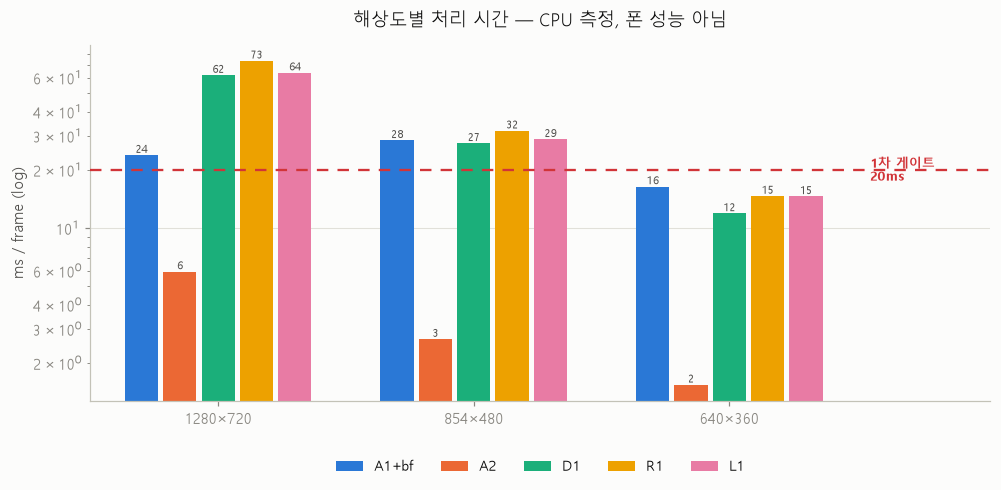

문서 6-3-2 와 대조: A2 6.2ms · A1+bf 17.6ms 통과 / D1 82.9 · R1 92.7 · L1 83.8 탈락.
이 머신 수치가 다르면 CPU 성능 차이다 — 순위가 같은지만 보면 된다.

⚠️ A1+bf 의 해상도별 막대는 9-1 의 병렬화 효율 문제를 안고 있다.
   같은 해상도에서의 arm 간 비교는 유효하지만, **해상도 간 비교는 하지 말 것.**


In [36]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(SIZES))
w = 0.15

for i, name in enumerate(series):
    off = (i - (len(series) - 1) / 2) * w
    vals = speed[name]
    bars = ax.bar(x + off, vals, width=w - 0.02, color=ARM_COLOR[name],
                  zorder=2, label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center",
                va="bottom", fontsize=7.5, color="#52514e")

ax.axhline(GATE_MS, color="#d13438", lw=1.5, ls=(0, (5, 4)), zorder=4)
# 막대와 겹치지 않는 유일한 자리는 플롯 밖이다 — 오른쪽에 여백을 만들어 거기 둔다.
# (막대 위·아래 어디에 놓아도 어느 해상도 그룹과는 반드시 충돌한다)
ax.set_xlim(-0.5, len(SIZES) - 0.5 + 0.52)
ax.annotate(f"1차 게이트\n{GATE_MS:.0f}ms", (len(SIZES) - 0.45, GATE_MS),
            fontsize=8.5, color="#d13438", va="center", ha="left", fontweight="bold")

ax.set_yscale("log")  # 게이트 통과군과 탈락군이 한 자릿수 이상 벌어진다
ax.set_xticks(x)
ax.set_xticklabels([f"{w_}×{h_}" for w_, h_ in SIZES])
ax.set_ylabel("ms / frame (log)", fontsize=9.5)
ax.set_title("해상도별 처리 시간 — CPU 측정, 폰 성능 아님",
             fontsize=11.5, color=INK, pad=12)
ax.legend(frameon=False, fontsize=9, ncol=5, labelcolor=INK,
          loc="upper center", bbox_to_anchor=(0.5, -0.13))
ax.grid(axis="y", lw=0.7, zorder=0)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

print("문서 6-3-2 와 대조: A2 6.2ms · A1+bf 17.6ms 통과 / D1 82.9 · R1 92.7 · L1 83.8 탈락.")
print("이 머신 수치가 다르면 CPU 성능 차이다 — 순위가 같은지만 보면 된다.")
if violations:
    print(f"\n⚠️ {', '.join(violations)} 의 해상도별 막대는 9-1 의 병렬화 효율 문제를 안고 있다.")
    print("   같은 해상도에서의 arm 간 비교는 유효하지만, **해상도 간 비교는 하지 말 것.**")

---

## 정리 — 이 노트북에서 확인할 것 / 확인할 수 없는 것

### ✅ LOL 로 확인 가능

| # | 확인 사항 | 어디서 |
|---|-----------|--------|
| 1 | 각 기법이 암부를 **얼마나** 끌어올리는가 | 3절 · 4절 |
| 2 | A1/A2 는 *탈색*, D1/R1/L1 은 *캐스트* — 색 결함의 종류가 다른가 | 3절 (GT 열과 대조) |
| 3 | **D1/R1/L1 의 암부 노이즈가 A1+bf 보다 심한가** — 지표는 반대로 말한다 | 5절 vs 7절 |
| 4 | PSNR 과 SSIM 이 **서로 다른 arm** 을 가리키는가 (H1 예비 신호) | 6절 |
| 5 | `+bf` 가 노이즈를 줄이는 대가로 무엇을 지우는가 | 8절 |
| 6 | 속도 순위가 문서 6-3-2 와 일치하는가 | 9절 |

**3번이 가장 중요하다.** 눈으로 본 것과 지표가 어긋나면 **지표를 고쳐야지 눈을 의심하면 안 된다.**
이것이 문서 7장의 최우선 미결 항목(**노이즈 지표 재설계**)이다.

### 📌 이 노트북에서 새로 나온 것 — 문서에 반영 필요

| 발견 | 내용 | 영향 |
|------|------|------|
| **GT 지표가 육안 기각안을 선택한다** | 6절에서 `D1`·`R1`·`L1` 이 PSNR·SSIM 모두 `A1+bf`·`A2` 를 이긴다. 그런데 5절 육안으로는 이들이 가장 지저분하다 | **가설 H1 의 직접 증거.** 문서 6-1 은 A1 vs A2 만 비교해 이 역전을 못 봤다 |
| **정규화 대비 지표도 무너진다** | 7절 — LOL 처럼 극단적으로 어두운 입력에서는 밝기배율이 3~9배라, 그것으로 나누는 정규화가 대비 이득을 상쇄해 대부분 1.0 아래로 떨어진다 | 문서 7장 "노이즈 지표 재설계"의 범위를 **대비 지표까지** 넓혀야 한다 |
| **저해상도 처리의 이득이 자동이 아니다** | 9-1 — 단일 스레드에서는 비용이 픽셀 수에 정확히 비례하지만, 멀티스레드에서는 720p 만 병렬화 이득을 받고 저해상도는 손해를 본다 | `hardware_inference.md` 5장 "내부 처리 해상도 하향" 방침은 **목표 런타임에서 재측정**이 필요하다 |

### ❌ LOL 로는 확인 불가 — 실제 야간 데이터가 필요하다

| 확인 사항 | 왜 불가능한가 | 필요한 것 |
|-----------|---------------|-----------|
| **글레어(눈부심) 억제** | `low` 의 포화 광원이 **0.00%** — 가로등·전조등이 없다 (1절) | ExDark · NightOwls · 자체 야간 촬영 |
| 실제 야간 노이즈 거동 | `low` 가 GT 보다 **깨끗하다** — 감광 합성 (1절) | 실제 저조도 촬영본 |
| 플리커 · 시간축 이득 | 정지영상이라 원리적으로 측정 불가 (`lowlight_classical.md` 3장) | 연속 **영상** (NightOwls recording) |
| 최종 arm 채택 | 판정 지표가 탐지 mAP 인데 라벨이 없다 | `data.md` 2-3-3 의 4-arm 실험 |

> **이 노트북은 판정용이 아니라 거동 확인용이다.**
> LOL 에서 좋아 보이는 arm 이 야간에서도 좋다는 보장은 없다 — 문서 6-2 에서
> **합성 데이터와 실제 야간의 결론이 실제로 갈렸다**(A1/A2 순위 역전).